# Regressão Linear com Dados de Energia Solar (PVGIS)

**Objetivo:** estimar a potência de um sistema fotovoltaico a partir de variáveis do tempo (irradiância, temperatura, vento, altura do Sol) e comparar dois modelos de Regressão Linear.

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Localização e período escolhidos
(Registro exigido: cidade, latitude, longitude, período e endereço da requisição.)

In [2]:
cidade = "São Paulo - SP"
latitude = -23.5505
longitude = -46.6333
ano_inicio = 2022
ano_fim = 2022          # 1 ano = 8760 linhas horárias

URL = "https://re.jrc.ec.europa.eu/api/v5_3/seriescalc"   # se der erro, tente v5_2
params = {
    "lat": latitude, "lon": longitude,
    "startyear": ano_inicio, "endyear": ano_fim,
    "pvcalculation": 1,      # pede o cálculo da potência (coluna P)
    "peakpower": 1,          # sistema de 1 kWp
    "loss": 14,              # perdas do sistema (%)
    "angle": 23,             # inclinação ~ latitude
    "aspect": 180,           # voltado para o Norte
    "outputformat": "json",
}

resposta = requests.get(URL, params=params, timeout=120)
resposta.raise_for_status()
dados = resposta.json()

print("Cidade:", cidade, "| lat:", latitude, "| lon:", longitude)
print("Período:", ano_inicio, "a", ano_fim)
print("Endereço da requisição:", resposta.url)
print("Status:", resposta.status_code)

Cidade: São Paulo - SP | lat: -23.5505 | lon: -46.6333
Período: 2022 a 2022
Endereço da requisição: https://re.jrc.ec.europa.eu/api/v5_3/seriescalc?lat=-23.5505&lon=-46.6333&startyear=2022&endyear=2022&pvcalculation=1&peakpower=1&loss=14&angle=23&aspect=180&outputformat=json
Status: 200


## 2. Obtenção e organização dos dados
A resposta é um JSON. As medições horárias ficam em `outputs → hourly`. Vamos ver a estrutura e as unidades antes de montar o DataFrame.

In [3]:
print(dados.keys())
print(dados["outputs"].keys())
print(dados["meta"]["outputs"]["hourly"])   # nome e unidade de cada variável
dados["outputs"]["hourly"][:2]

dict_keys(['inputs', 'outputs', 'meta'])
dict_keys(['hourly'])
{'type': 'time series', 'timestamp': 'hourly averages', 'variables': {'P': {'description': 'PV system power', 'units': 'W'}, 'G(i)': {'description': 'Global irradiance on the inclined plane (plane of the array)', 'units': 'W/m2'}, 'H_sun': {'description': 'Sun height', 'units': 'degree'}, 'T2m': {'description': '2-m air temperature', 'units': 'degree Celsius'}, 'WS10m': {'description': '10-m total wind speed', 'units': 'm/s'}, 'Int': {'description': '1 means solar radiation values are reconstructed'}}}


[{'time': '20220101:0003',
  'P': 0.0,
  'G(i)': 0.0,
  'H_sun': 0.0,
  'T2m': 19.85,
  'WS10m': 0.21,
  'Int': 0.0},
 {'time': '20220101:0103',
  'P': 0.0,
  'G(i)': 0.0,
  'H_sun': 0.0,
  'T2m': 19.85,
  'WS10m': 0.9,
  'Int': 0.0}]

Variáveis confirmadas na resposta:
- P = potência do sistema (W) → **alvo**
- G (i) = irradiância no plano do painel (W/m²)
- H_sun = altura do Sol (graus)
- T2m = temperatura do ar a 2 m (°C)
- WS10m = velocidade do vento a 10 m (m/s)
- Int = indicador de dado interpolado (não é necessário → descartado)

In [4]:
df = pd.DataFrame(dados["outputs"]["hourly"])
df["time"] = pd.to_datetime(df["time"], format="%Y%m%d:%H%M")
df = df[["time", "P", "G(i)", "H_sun", "T2m", "WS10m"]]   # só o necessário
df.head()

,time,P,G(i),H_sun,T2m,WS10m
0,2022-01-01 00:03:00,0.0,0.0,0.0,19.85,0.21
1,2022-01-01 01:03:00,0.0,0.0,0.0,19.85,0.90
2,2022-01-01 02:03:00,0.0,0.0,0.0,19.80,1.38
3,2022-01-01 03:03:00,0.0,0.0,0.0,19.79,1.72
4,2022-01-01 04:03:00,0.0,0.0,0.0,19.59,2.07


## 3. Inspeção inicial do DataFrame

In [5]:
print("Linhas e colunas:", df.shape)
print("Colunas:", list(df.columns))
print()
df.info()

Linhas e colunas: (8760, 6)
Colunas: ['time', 'P', 'G(i)', 'H_sun', 'T2m', 'WS10m']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    8760 non-null   datetime64[ns]
 1   P       8760 non-null   float64       
 2   G(i)    8760 non-null   float64       
 3   H_sun   8760 non-null   float64       
 4   T2m     8760 non-null   float64       
 5   WS10m   8760 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 410.8 KB


In [6]:
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print()
df.describe()

Valores ausentes por coluna:
time     0
P        0
G(i)     0
H_sun    0
T2m      0
WS10m    0
dtype: int64



,time,P,G(i),H_sun,T2m,WS10m
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2022-07-02 11:32:59.999999488,154.367639,202.514197,18.675506,19.079078,2.298228
min,2022-01-01 00:03:00,0.000000,0.000000,0.000000,7.460000,0.000000
25%,2022-04-02 05:48:00,0.000000,0.000000,0.000000,15.910000,1.380000
50%,2022-07-02 11:33:00,0.000000,0.000000,0.000000,19.090000,2.070000
75%,2022-10-01 17:18:00,268.825000,345.655000,36.820000,22.150000,3.030000
max,2022-12-31 23:03:00,854.430000,1120.680000,89.840000,31.420000,9.380000
std,NaN,235.755182,306.711827,24.328160,4.429219,1.290688


In [7]:
sem_irradiancia = (df["G(i)"] == 0).sum()
sem_geracao = (df["P"] == 0).sum()
print(f"Registros com G(i) = 0 (sem irradiância): {sem_irradiancia} ({sem_irradiancia/len(df):.1%})")
print(f"Registros com P = 0 (sem geração):        {sem_geracao} ({sem_geracao/len(df):.1%})")

Registros com G(i) = 0 (sem irradiância): 4454 (50.8%)
Registros com P = 0 (sem geração):        4567 (52.1%)


### Decisão: manter ou remover registros noturnos?
À noite não há Sol: G(i) = 0 e P = 0. Esses registros a resposta é sempre zero e ocupam cerca de metade da tabela. Se ficarem, o modelo parece bom só por acertar zeros, e o R² fica inflado sem mostrar se ele explica a geração de dia.

Decisão: remover as linhas com G (i) = 0 e usar somente o período com Sol para treinar e avaliar. O df original continua guardado, o conjunto filtrado se chama df_dia.

In [8]:
df_dia = df[df["G(i)"] > 0].copy()
print("Antes:", df.shape, "| Depois:", df_dia.shape)
df_dia.describe()

Antes: (8760, 6) | Depois: (4306, 6)


,time,P,G(i),H_sun,T2m,WS10m
count,4306,4306.000000,4306.000000,4306.000000,4306.000000,4306.000000
mean,2022-07-03 16:29:44.366000640,314.040994,411.988939,37.992901,21.100992,2.647346
min,2022-01-01 09:03:00,0.000000,0.940000,1.380000,7.460000,0.000000
25%,2022-03-28 13:18:00,74.950000,110.340000,20.402500,18.112500,1.520000
50%,2022-07-04 12:33:00,279.515000,355.850000,37.135000,21.400000,2.480000
75%,2022-10-09 05:48:00,539.797500,690.675000,52.507500,24.310000,3.590000
max,2022-12-31 21:03:00,854.430000,1120.680000,89.840000,31.420000,9.380000
std,NaN,250.856686,324.158742,21.682001,4.379543,1.438626


## 4. Definição do problema de regressão
Problema: estimar a potência P produzida pelo sistema.

- y = p (o que queremos prever).
- Candidatas para X: G (i) (mais luz → mais energia), T2m (calor reduz a eficiência do painel), WS10m (vento resfria o painel) e H_sun (altura do Sol, ligada à quantidade de luz).
- A escolha final de X para cada modelo vem depois dos gráficos e da correlação.

In [9]:
y = df_dia["P"]
candidatas = ["G(i)", "H_sun", "T2m", "WS10m"]
print(y.name, "| linhas:", len(y))

P | linhas: 4306


## 5. Visualização das relações

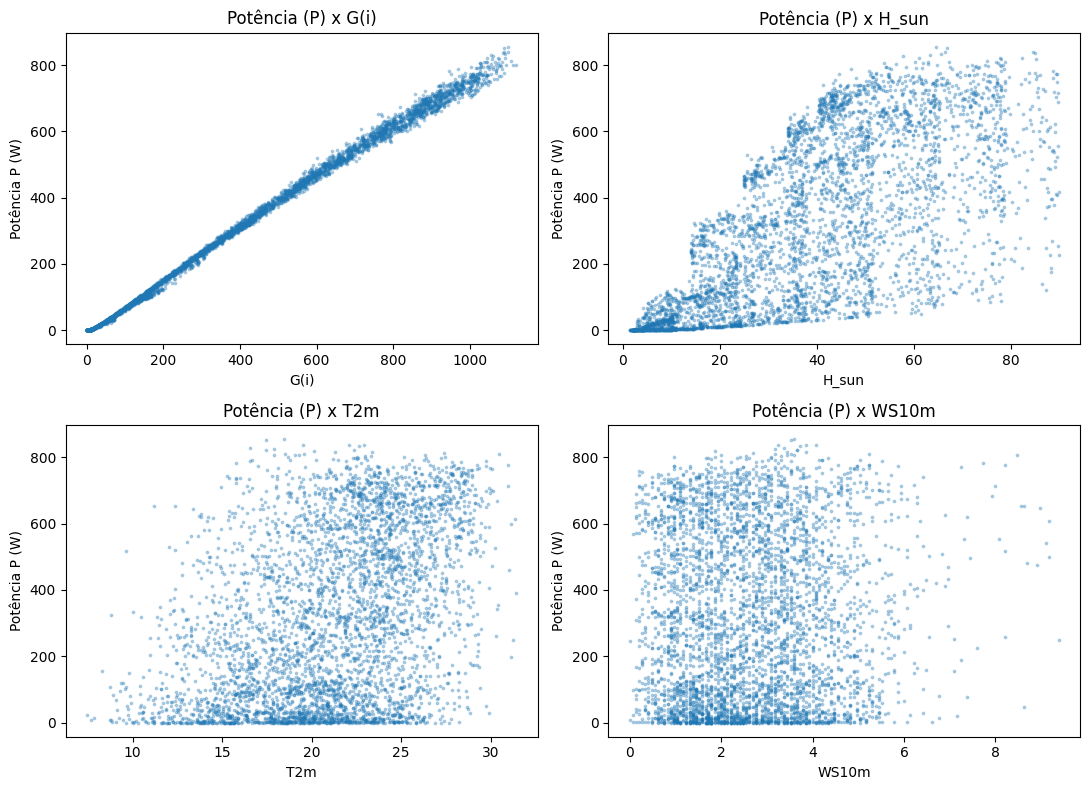

In [10]:
fig, eixos = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(eixos.ravel(), candidatas):
    ax.scatter(df_dia[col], y, s=3, alpha=0.3)
    ax.set_title(f"Potência (P) x {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Potência P (W)")
plt.tight_layout()
plt.show()

## 6. Matriz de correlação

           P   G(i)  H_sun    T2m  WS10m
P      1.000  0.998  0.685  0.412  0.036
G(i)   0.998  1.000  0.689  0.434  0.012
H_sun  0.685  0.689  1.000  0.440  0.128
T2m    0.412  0.434  0.440  1.000 -0.095
WS10m  0.036  0.012  0.128 -0.095  1.000


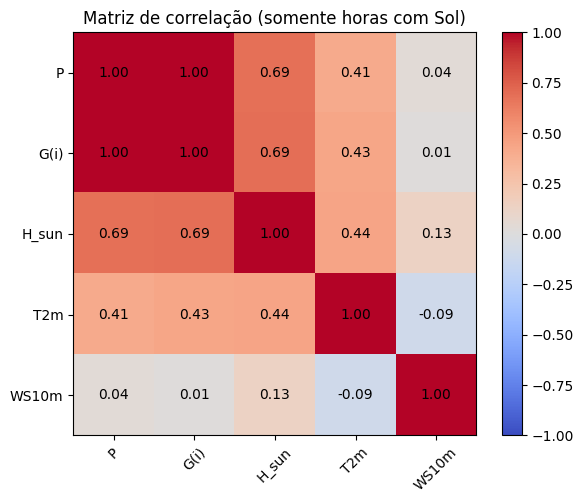

In [11]:
colunas_num = ["P"] + candidatas
corr = df_dia[colunas_num].corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(colunas_num))); ax.set_xticklabels(colunas_num, rotation=45)
ax.set_yticks(range(len(colunas_num))); ax.set_yticklabels(colunas_num)
for i in range(len(colunas_num)):
    for j in range(len(colunas_num)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.colorbar(im)
ax.set_title("Matriz de correlação (somente horas com Sol)")
plt.tight_layout()
plt.show()

In [12]:
corr_y = corr["P"].drop("P")
print("Correlação de cada variável com P (da maior para a menor, em módulo):")
print(corr_y.reindex(corr_y.abs().sort_values(ascending=False).index).round(3))
maior = corr_y.abs().idxmax()
print(f"\nMaior correlação linear com a potência: {maior} (r = {corr_y[maior]:.3f})")
baixas = corr_y[corr_y.abs() < 0.3].index.tolist()
print("Variáveis com correlação baixa (|r| < 0,3):", baixas if baixas else "nenhuma")

Correlação de cada variável com P (da maior para a menor, em módulo):
G(i)     0.998
H_sun    0.685
T2m      0.412
WS10m    0.036
Name: P, dtype: float64

Maior correlação linear com a potência: G(i) (r = 0.998)
Variáveis com correlação baixa (|r| < 0,3): ['WS10m']


Os valores perto de 1 (ou −1) indicam relação linear forte. Consequentimente, perto de 0, relação fraca. O resultado acima responde às perguntas da seção 6: qual variável tem maior correlação, se há variáveis com correlação baixa e se isso combina com os gráficos de dispersão (G (i) deve formar uma "faixa" quase reta; T2m e WS10m devem aparecer mais espalhadas).

## 7. Separação treino/teste
20% dos dados para teste, random_state=42 para o resultado ser reproduzível. A separação é feita junto com cada modelo (seções 8 e 9), pois cada um usa um X diferente. Como usam o mesmo random_state, as **mesmas linhas** vão para treino e teste nos dois casos, e a comparação fica justa.

## 8. Modelo 1 — somente irradiância
X1 = G (i). É a variável fisicamente mais ligada à potência; serve como modelo base.

In [13]:
vars1 = ["G(i)"]
X1 = df_dia[vars1]

X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

modeloLR1 = LinearRegression()
modeloLR1.fit(X_train, y_train)
y_pred1 = modeloLR1.predict(X_test)

mae1 = mean_absolute_error(y_test, y_pred1)
mse1 = mean_squared_error(y_test, y_pred1)
r2_1 = r2_score(y_test, y_pred1)
print(f"Modelo 1 -> MAE: {mae1:.3f} | MSE: {mse1:.3f} | R²: {r2_1:.4f}")

X_train: (3444, 1) | X_test: (862, 1)
y_train: (3444,) | y_test: (862,)
Modelo 1 -> MAE: 9.934 | MSE: 203.379 | R²: 0.9969


## 9. Modelo 2 — todas as variáveis
X2 = G (i), H_sun, T2m, WS10m. Pergunta: acrescentar altura do Sol, temperatura e vento melhora a previsão?

In [14]:
vars2 = ["G(i)", "H_sun", "T2m", "WS10m"]
X2 = df_dia[vars2]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=42)
print("X_train2:", X_train2.shape, "| X_test2:", X_test2.shape)
print("y_train2:", y_train2.shape, "| y_test2:", y_test2.shape)

modeloLR2 = LinearRegression()
modeloLR2.fit(X_train2, y_train2)
y_pred2 = modeloLR2.predict(X_test2)

mae2 = mean_absolute_error(y_test2, y_pred2)
mse2 = mean_squared_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)
print(f"Modelo 2 -> MAE: {mae2:.3f} | MSE: {mse2:.3f} | R²: {r2_2:.4f}")
print(dict(zip(vars2, modeloLR2.coef_.round(4))))

X_train2: (3444, 4) | X_test2: (862, 4)
y_train2: (3444,) | y_test2: (862,)
Modelo 2 -> MAE: 9.178 | MSE: 141.700 | R²: 0.9978
{'G(i)': np.float64(0.7822), 'H_sun': np.float64(-0.044), 'T2m': np.float64(-1.2947), 'WS10m': np.float64(3.8462)}


## 10. Comparação dos modelos

In [15]:
tabela = pd.DataFrame({
    "Modelo": ["Modelo 1", "Modelo 2"],
    "Variáveis utilizadas": [", ".join(vars1), ", ".join(vars2)],
    "MAE": [mae1, mae2],
    "MSE": [mse1, mse2],
    "R²": [r2_1, r2_2],
})
tabela

,Modelo,Variáveis utilizadas,MAE,MSE,R²
0,Modelo 1,G(i),9.934389,203.379096,0.996857
1,Modelo 2,"G(i), H_sun, T2m, WS10m",9.177643,141.700064,0.997810


## 11. Análise dos resultados
As respostas numéricas abaixo são calculadas a partir da tabela; a interpretação vem logo depois.

In [16]:
m_r2  = tabela.loc[tabela["R²"].idxmax(), "Modelo"]
m_mae = tabela.loc[tabela["MAE"].idxmin(), "Modelo"]
m_mse = tabela.loc[tabela["MSE"].idxmin(), "Modelo"]

print(f"1. Maior R²:  {m_r2}  (M1 = {r2_1:.4f} | M2 = {r2_2:.4f})")
print(f"2. Menor MAE: {m_mae}  (M1 = {mae1:.3f} | M2 = {mae2:.3f})")
print(f"3. Menor MSE: {m_mse}  (M1 = {mse1:.3f} | M2 = {mse2:.3f})")
print("4. As três métricas apontam para o mesmo modelo?", "SIM" if m_r2 == m_mae == m_mse else "NÃO")
melhor = m_r2
print(f"5. Variável de maior correlação: {maior}. Ela está nos dois modelos, mas o melhor modelo é o {melhor}"
      f" ({'com mais variáveis' if melhor == 'Modelo 2' else 'só com ela'}).")
print("6. Correlação linear de cada variável com P:")
for v, r in corr_y.items():
    forca = "forte" if abs(r) >= 0.7 else "moderada" if abs(r) >= 0.3 else "fraca"
    print(f"     {v}: r = {r:.3f} ({forca})")

1. Maior R²:  Modelo 2  (M1 = 0.9969 | M2 = 0.9978)
2. Menor MAE: Modelo 2  (M1 = 9.934 | M2 = 9.178)
3. Menor MSE: Modelo 2  (M1 = 203.379 | M2 = 141.700)
4. As três métricas apontam para o mesmo modelo? SIM
5. Variável de maior correlação: G(i). Ela está nos dois modelos, mas o melhor modelo é o Modelo 2 (com mais variáveis).
6. Correlação linear de cada variável com P:
     G(i): r = 0.998 (forte)
     H_sun: r = 0.685 (moderada)
     T2m: r = 0.412 (moderada)
     WS10m: r = 0.036 (fraca)


## Interpretação dos resultados

O Modelo 2 foi o melhor nas três métricas: maior R² (0,9978 contra 0,9969) e menores erros (MAE 9,18 contra 9,93 e MSE 141,7 contra 203,4). Como as três concordam, a conclusão é segura.

A irradiância G (i) é a variável mais ligada à potência (correlação 0,998) e está nos dois modelos. Mesmo assim, o Modelo 2 ganhou, porque temperatura e altura do Sol acrescentam informação nova. Ou seja, correlação alta sozinha não garante o melhor modelo. O vento quase não ajudou (correlação 0,036).

Nos gráficos, G (i) contra P forma quase uma reta. As outras variáveis ficam mais espalhadas.

O que atrapalha um modelo linear: nuvens e poeira, o calor reduzindo a eficiência do painel, relações que são curvas (como a altura do Sol) e o limite de potência do inversor.

## Resumo final
O modelo vencedor é o indicado nas respostas 1 a 3 da seção 11. Os dados noturnos foram removidos para o R² refletir a qualidade real da previsão durante o dia. Para melhorar: testar modelos não lineares (ex.: Random Forest) ou criar variáveis novas (hora do dia, mês).